# Action client node

## Imports

In [1]:
from assignment_2_2024.msg import PlanningAction, PlanningGoal

import rospy
import actionlib
import threading
import ipywidgets as widgets
import matplotlib.pyplot as plt
import tf
import numpy as np

from nav_msgs.msg import Odometry
from ass2_ros1.msg import RobotVelocity
from sensor_msgs.msg import LaserScan
from tf.transformations import quaternion_matrix 
from matplotlib.animation import FuncAnimation

%matplotlib widget

## Globals


In [2]:
client = None
goal = None
latest_feedback = None

active_goal = False
reached_goals = 0
not_reached_goals = 0
minimum_obstacle_distance = 0
robot_positions = {"x": [], "y": []}

vel_pub = None

In [3]:
def read_feedback(feedback):
    global target_reached, active_goal, latest_feedback
    latest_feedback = feedback

    if (active_goal and feedback.stat == 'Target reached!'):
        reached_goals = reached_goals + 1
        active_goal = False
        goal = None

In [4]:
def cancel_goal():
    global client, not_reached_goals, active_goal
    client.cancel_goal
    not_reached_goals = not_reached_goals + 1
    goal = None
    active_goal = False

In [5]:
def publish_robot_velocity(msg):
    vel = RobotVelocity()
    vel.x = msg.pose.pose.position.x
    vel.y = msg.pose.pose.position.y
    vel.vel_x = msg.twist.twist.linear.x
    vel.vel_z = msg.twist.twist.angular.z
    
    robot_positions["x"].append(vel.x)
    robot_positions["y"].append(vel.y)


    vel_pub.publish(vel)

In [6]:
def update_goal(x, y):
    global goal, active_goal, not_reached_goals
    goal = PlanningGoal()
    
    if active_goal:
        not_reached_goals = not_reached_goals + 1
    else:
        active_goal = True

    goal.target_pose.header.frame_id = "map"
    goal.target_pose.pose.position.x = x
    goal.target_pose.pose.position.y = y
    
    client.send_goal(goal, feedback_cb=read_feedback)

In [7]:
def print_status():
    if (not goal):
        print("No goal set yet")
        return 
    
    #TODO: return the status
    print(goal)
    
    if (not latest_feedback):
        print("No feedacks received from the server yet!")
        return
    print(latest_feedback)

In [8]:
def laserscan_callback(laserMsg):
    global minimum_obstacle_distance
    minimum_obstacle_distance = min(laserMsg.ranges)   

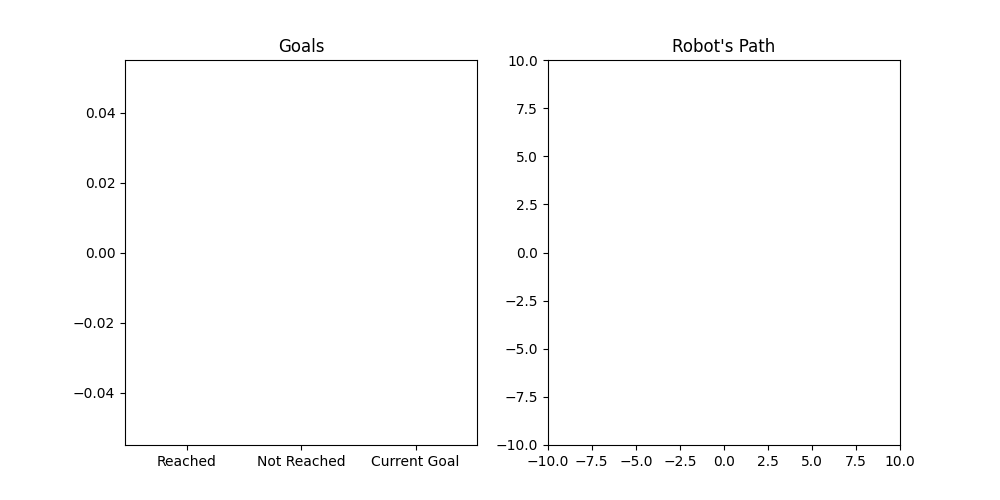

In [9]:
rospy.init_node('action_client')
client = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)

vel_pub = rospy.Publisher("/robot_status", RobotVelocity, queue_size = 10)
rospy.Subscriber("/odom", Odometry, publish_robot_velocity)
rospy.Subscriber("/scan", LaserScan, laserscan_callback)

# input for new goal
fin_goal_x = widgets.FloatText(value=1,description='X coordinate of target:')
fin_goal_y = widgets.FloatText(value=1,description='Y coordinate of targe:')
btn_new_goal = widgets.Button(description = "Set new Goal", button_style='success')
btn_new_goal.on_click(lambda _: update_goal(fin_goal_x.value, fin_goal_y.value))

# cancel goal
btn_cancel_goal = widgets.Button(description = "Cancel Goal", button_style='danger')
btn_cancel_goal.on_click(lambda _: cancel_goal())

# print status
btn_print_status = widgets.Button(description = "Print Status", button_style='info')
btn_print_status.on_click(lambda _: print_status())

# closest obstacle distance

f_obstacle_distance = widgets.FloatText(description='Obst. distance [m]: ', disabled=True)
f_obstacle_distance.value = 0


# Layout
outputs = widgets.VBox([f_obstacle_distance])
inputs = widgets.VBox([fin_goal_x, fin_goal_y, btn_new_goal, btn_cancel_goal, btn_print_status])

layout = widgets.HBox([inputs, outputs])

display(layout)

# graphs
fig, (axs_goals, axs_position) = plt.subplots(1, 2, figsize=(10, 5))

x = ['Reached', 'Not Reached', 'Current Goal']
bar_container = axs_goals.bar(x, [0, 0, 0])
axs_goals.set_title("Goals")

def update_goals_plot(frame):
    y = [reached_goals, not_reached_goals, 1 if active_goal else 0]
    axs_goals.set_ylim(0, max(y))

    for bar, new_height in zip(bar_container.patches, y):
        bar.set_height(new_height)
    
    return axs_goals, bar_container

bar_animation = FuncAnimation(fig, func=update_goals_plot, cache_frame_data=False)


ln, = axs_position.plot(robot_positions["x"], robot_positions["y"])
axs_position.set_title("Robot's Path")
axs_position.set_xlim(-10, 10)
axs_position.set_ylim(-10, 10)

def update_position_plot(frame):
    ln.set_xdata(robot_positions["x"])
    ln.set_ydata(robot_positions["y"])
    return ln

positon_animation = FuncAnimation(fig, func=update_position_plot,cache_frame_data=False)

plt.show()

In [11]:
def update_widgets():
    f_obstacle_distance.value = minimum_obstacle_distance

def spin():
    rospy.spin()
    
widget_thread = threading.Thread(target=update_widgets)
widget_thread.start()

spin_thread = threading.Thread(target=spin)
spin_thread.start()

## New heading